In [ ]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(
            filename="etl_mongo_sql_taller_final.log",
            encoding="utf-8",
            mode="a"
        )
    ]
)

logging.info("Sistema de logging configurado: ETL Mongo → SQL Server")


In [71]:
import pandas as pd
import logging
import pyodbc
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [ ]:
server = r"DESKTOP-CR7\SQLEXPRESS"
db_sql = "WideWorldImporters"
driver = "ODBC Driver 17 for SQL Server"
##Conexion a SQL

conn_str = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={db_sql};"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)

# Establecer conexión
conn_sql = pyodbc.connect(conn_str)
cursor = conn_sql.cursor()

logging.info(f"Conexión exitosa a SQL Server (BD: {db_sql})")

# Verificar base conectada
cursor.execute("SELECT DB_NAME() AS CurrentDB")
db_actual = cursor.fetchone()[0]
print("Base actual:", db_actual)



Base actual: WideWorldImporters


In [ ]:
from pymongo import MongoClient
##Conexion a mongodb

client = MongoClient("localhost", 27017)

db_mongo = client["ejemplo_pymongo"]   
col_cars = db_mongo["cars"]    
logging.info("Conectado a MongoDB - BD: %s, colección: %s",
             db_mongo.name, col_cars.name)

# documentos
for doc in col_cars.find().limit(3):
    print(doc)

{'_id': ObjectId('69222ca8dc4e14216ce520fb'), 'CarName': 'alfa-romero giulia', 'fueltype': 'gas', 'aspiration': 'std', 'doornumber': '2', 'carbody': 'convertible', 'drivewheel': 'rwd', 'enginelocation': 'front', 'wheelbase': 886.0, 'carlength': 1688.0, 'carwidth': 641.0, 'carheight': 488.0, 'curbweight': 2548, 'enginetype': 'dohc', 'cylindernumber': '4', 'enginesize': 130, 'fuelsystem': 'mpfi', 'boreratio': 347.0, 'stroke': 268.0, 'compressionratio': 9.0, 'horsepower': 111, 'peakrpm': 5000, 'citympg': 21, 'highwaympg': 27, 'price': 13495.0}
{'_id': ObjectId('69222ca8dc4e14216ce520fc'), 'CarName': 'alfa-romero stelvio', 'fueltype': 'gas', 'aspiration': 'std', 'doornumber': '2', 'carbody': 'convertible', 'drivewheel': 'rwd', 'enginelocation': 'front', 'wheelbase': 886.0, 'carlength': 1688.0, 'carwidth': 641.0, 'carheight': 488.0, 'curbweight': 2548, 'enginetype': 'dohc', 'cylindernumber': '4', 'enginesize': 130, 'fuelsystem': 'mpfi', 'boreratio': 347.0, 'stroke': 268.0, 'compressionratio

### 2. Cargar en df

In [74]:
query_cars = ''' 
SELECT 
    CarName,
    fueltype,
    aspiration,
    doornumber,
    carbody,
    drivewheel,
    enginelocation,
    wheelbase,
    carlength,
    carwidth,
    carheight,
    curbweight,
    curbweight,
    enginetype,
    cylindernumber,
    enginesize,
    fuelsystem,
    boreratio,
    stroke,
    compressionratio,
    horsepower,
    peakrpm,
    citympg,
    highwaympg,
    price
FROM CarPrice_Assignment
'''

df_cars = pd.read_sql (query_cars, conn_sql)
df_cars.head()

C:\Users\juand\AppData\Local\Temp\ipykernel_8700\3178373033.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cars = pd.read_sql (query_cars, conn_sql)


,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,886.0,1688.0,641.0,...,130,mpfi,347.0,268.0,9.0,111,5000,21,27,13495.0
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,886.0,1688.0,641.0,...,130,mpfi,347.0,268.0,9.0,111,5000,21,27,16500.0
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,945.0,1712.0,655.0,...,152,mpfi,268.0,347.0,9.0,154,5000,19,26,16500.0
3,audi 100 ls,gas,std,four,sedan,fwd,front,998.0,1766.0,662.0,...,109,mpfi,319.0,34.0,10.0,102,5500,24,30,13950.0
4,audi 100ls,gas,std,four,sedan,4wd,front,994.0,1766.0,664.0,...,136,mpfi,319.0,34.0,8.0,115,5500,18,22,17450.0


In [ ]:
df_cars[['marca', 'linea']] = df_cars['CarName'].str.split(' ', n=1, expand=True) 

In [76]:
df_cars.head()

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,marca,linea
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,886.0,1688.0,641.0,...,347.0,268.0,9.0,111,5000,21,27,13495.0,alfa-romero,giulia
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,886.0,1688.0,641.0,...,347.0,268.0,9.0,111,5000,21,27,16500.0,alfa-romero,stelvio
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,945.0,1712.0,655.0,...,268.0,347.0,9.0,154,5000,19,26,16500.0,alfa-romero,Quadrifoglio
3,audi 100 ls,gas,std,four,sedan,fwd,front,998.0,1766.0,662.0,...,319.0,34.0,10.0,102,5500,24,30,13950.0,audi,100 ls
4,audi 100ls,gas,std,four,sedan,4wd,front,994.0,1766.0,664.0,...,319.0,34.0,8.0,115,5500,18,22,17450.0,audi,100ls


In [77]:
df_cars['doornumber'].unique()

array(['two', 'four', 'five'], dtype=object)

In [ ]:
reemplazos_puertas = {
    'two': '2',
    'four': '4',
    'five': '5'
}

df_cars['doornumber'] = df_cars['doornumber'].replace(reemplazos_puertas, regex=True)



In [79]:
df_cars.head()

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,marca,linea
0,alfa-romero giulia,gas,std,2,convertible,rwd,front,886.0,1688.0,641.0,...,347.0,268.0,9.0,111,5000,21,27,13495.0,alfa-romero,giulia
1,alfa-romero stelvio,gas,std,2,convertible,rwd,front,886.0,1688.0,641.0,...,347.0,268.0,9.0,111,5000,21,27,16500.0,alfa-romero,stelvio
2,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,945.0,1712.0,655.0,...,268.0,347.0,9.0,154,5000,19,26,16500.0,alfa-romero,Quadrifoglio
3,audi 100 ls,gas,std,4,sedan,fwd,front,998.0,1766.0,662.0,...,319.0,34.0,10.0,102,5500,24,30,13950.0,audi,100 ls
4,audi 100ls,gas,std,4,sedan,4wd,front,994.0,1766.0,664.0,...,319.0,34.0,8.0,115,5500,18,22,17450.0,audi,100ls


In [80]:
df_cars['cylindernumber'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [ ]:
reemplazos_cilindros = {
    'two': '2',
    'three': '3',
    'four': '4',
    'five': '5',
    'six': '6',
    'seven': '7',
    'eight': '8'
}

df_cars['cylindernumber'] = df_cars['cylindernumber'].replace(reemplazos_cilindros, regex=True)


In [82]:
df_cars.head()

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,marca,linea
0,alfa-romero giulia,gas,std,2,convertible,rwd,front,886.0,1688.0,641.0,...,347.0,268.0,9.0,111,5000,21,27,13495.0,alfa-romero,giulia
1,alfa-romero stelvio,gas,std,2,convertible,rwd,front,886.0,1688.0,641.0,...,347.0,268.0,9.0,111,5000,21,27,16500.0,alfa-romero,stelvio
2,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,945.0,1712.0,655.0,...,268.0,347.0,9.0,154,5000,19,26,16500.0,alfa-romero,Quadrifoglio
3,audi 100 ls,gas,std,4,sedan,fwd,front,998.0,1766.0,662.0,...,319.0,34.0,10.0,102,5500,24,30,13950.0,audi,100 ls
4,audi 100ls,gas,std,4,sedan,4wd,front,994.0,1766.0,664.0,...,319.0,34.0,8.0,115,5500,18,22,17450.0,audi,100ls


In [ ]:
col_num= ['price']
df_cars=df_cars[df_cars['price']<=45000]

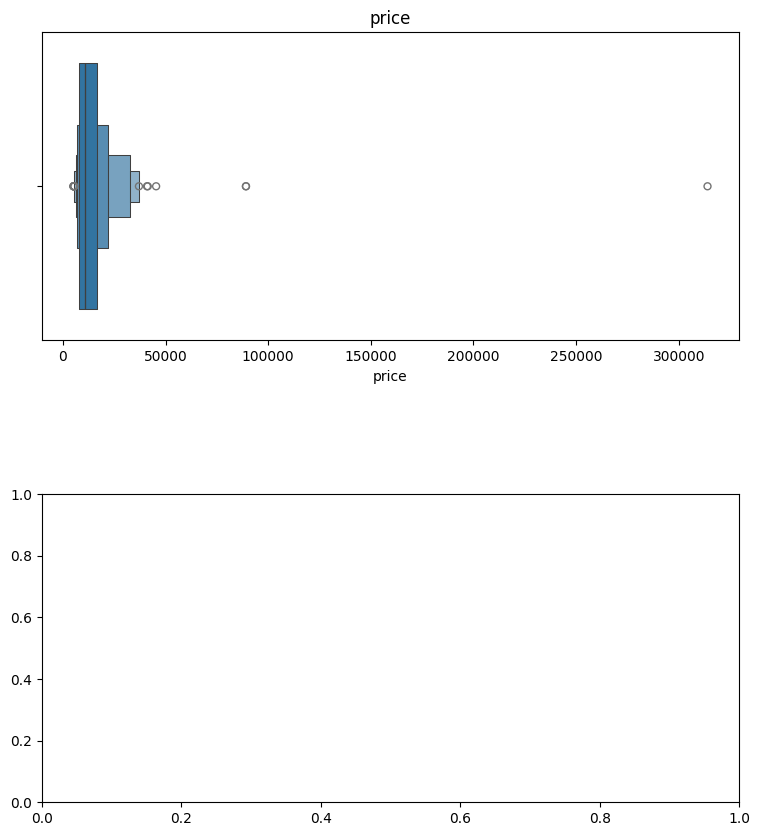

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 10))
fig.subplots_adjust(hspace=0.45)

for idx, columna in enumerate(col_num):
    sns.boxenplot(data=df_cars, x=columna, ax=axes[idx])
    axes[idx].set_title(f"{columna}", fontsize=12)


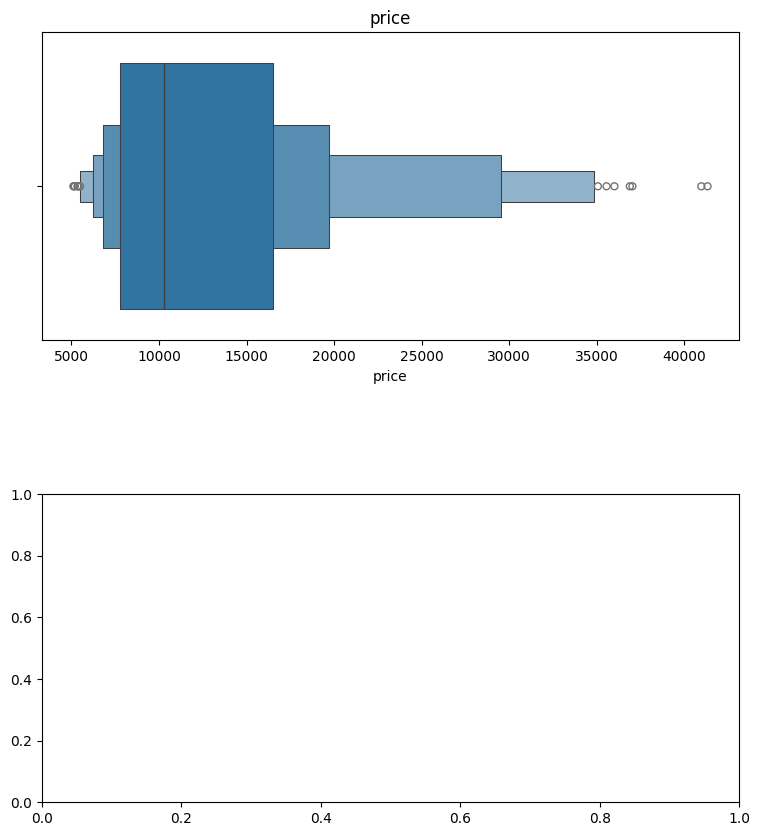

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(9, 10))
fig.subplots_adjust(hspace=0.45)

for idx, feature in enumerate(col_num):
    sns.boxenplot(data=df_cars, x=feature, ax=ax[idx])
    ax[idx].set_title(f"Distribución de: {feature}", fontsize=12)
    ax[idx].set_xlabel("")  
    ax[idx].tick_params(axis='x', rotation=15)


In [87]:
df_cars.head()

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,marca,linea
0,alfa-romero giulia,gas,std,2,convertible,rwd,front,886.0,1688.0,641.0,...,347.0,268.0,9.0,111,5000,21,27,13495.0,alfa-romero,giulia
1,alfa-romero stelvio,gas,std,2,convertible,rwd,front,886.0,1688.0,641.0,...,347.0,268.0,9.0,111,5000,21,27,16500.0,alfa-romero,stelvio
2,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,945.0,1712.0,655.0,...,268.0,347.0,9.0,154,5000,19,26,16500.0,alfa-romero,Quadrifoglio
3,audi 100 ls,gas,std,4,sedan,fwd,front,998.0,1766.0,662.0,...,319.0,34.0,10.0,102,5500,24,30,13950.0,audi,100 ls
4,audi 100ls,gas,std,4,sedan,4wd,front,994.0,1766.0,664.0,...,319.0,34.0,8.0,115,5500,18,22,17450.0,audi,100ls


In [ ]:
def etl_cars_sql_a_mongo():
    logging.info(">>> Iniciando ETL: SQL → MongoDB")
    t0 = time.time()

    try:
        # -------------------------------------------------
        # 1. Extracción desde SQL
        # -------------------------------------------------
        logging.info("Extrayendo datos de CarPrice_Assignment")

        query = """
        SELECT 
            CarName, fueltype, aspiration, doornumber, carbody, drivewheel,
            enginelocation, wheelbase, carlength, carwidth, carheight,
            curbweight, enginetype, cylindernumber, enginesize, fuelsystem,
            boreratio, stroke, compressionratio, horsepower, peakrpm,
            citympg, highwaympg, price
        FROM CarPrice_Assignment
        """

        df = pd.read_sql(query, conn_sql)
        logging.info("  -> %d filas recuperadas", len(df))

        if df.empty:
            logging.warning("No hay datos disponibles para migrar.")
            return

        # -------------------------------------------------
        # 2. Transformación
        # -------------------------------------------------
        logging.info("Aplicando transformaciones a los datos")

        # Separar marca y línea
        df[['marca', 'linea']] = df['CarName'].str.split(' ', n=1, expand=True)

        # Corrección numérica de textos
        mapa_puertas = {'two': '2', 'four': '4', 'five': '5'}
        df['doornumber'] = df['doornumber'].replace(mapa_puertas, regex=True)

        mapa_cilindros = {
            'two':'2','three':'3','four':'4','five':'5',
            'six':'6','seven':'7','eight':'8'
        }
        df['cylindernumber'] = df['cylindernumber'].replace(mapa_cilindros, regex=True)

        # Filtro del price
        df = df[df['price'] <= 45000]

        # Convertir a documentos
        documentos = df.to_dict(orient='records')

        logging.info("  -> %d documentos preparados", len(documentos))

        # -------------------------------------------------
        # 3. Carga a MongoDB
        # -------------------------------------------------
        logging.info("Insertando documentos en MongoDB")

        col_cars.insert_many(documentos)
        logging.info("Carga completada: %d documentos insertados", len(doc



C:\Users\juand\AppData\Local\Temp\ipykernel_8700\974164845.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cars = pd.read_sql (query_cars, conn_sql)
